In [33]:
from sklearn.datasets import load_digits

In [34]:
digit=load_digits()
digit

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [35]:
import numpy as np
import pandas as pd

In [36]:
df=pd.DataFrame(digit.data,columns=digit.feature_names)
df.shape

(1797, 64)

In [37]:
df['target']=digit.target

In [38]:
df.shape

(1797, 65)

In [39]:
df.sample(2)

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
562,0.0,0.0,11.0,13.0,12.0,12.0,3.0,0.0,0.0,5.0,...,0.0,0.0,1.0,12.0,16.0,12.0,2.0,0.0,0.0,5
1237,0.0,0.0,3.0,16.0,12.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,16.0,14.0,0.0,0.0,0.0,1


In [40]:
import matplotlib.pyplot as plt

In [41]:
X=digit.data
y=digit.target

In [42]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [43]:
X_train.shape

(1437, 64)

In [44]:
from sklearn.neighbors import KNeighborsClassifier

In [45]:
knn=KNeighborsClassifier()

In [46]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [47]:
import time
start=time.time()
y_pred=knn.predict(X_test)
print(time.time()-start)

0.013330221176147461


In [48]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred,y_test)

0.9861111111111112

In [49]:
# Step 1 Apply StandardScaler
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

# PCA

In [50]:
from sklearn.decomposition import PCA
pca=PCA(n_components=50)   # put the value of N_component is there column present in X_train all 64 now cut the point  50


In [51]:
X_train_pca=pca.fit_transform(X_train)
X_test_pca=pca.transform(X_test)

In [52]:
X_train_pca.shape

(1437, 50)

# Again Train

In [53]:
knn=KNeighborsClassifier()

In [54]:
knn.fit(X_train_pca,y_train)

KNeighborsClassifier()

In [55]:
import time
start=time.time()
y_pred_pca=knn.predict(X_test_pca)
print(time.time()-start)

0.013202667236328125


In [56]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred_pca,y_test)

0.975

In [57]:
for i in range(1,51):
    pca=PCA(n_components=i)
    X_train_pca=pca.fit_transform(X_train)
    X_test_pca=pca.transform(X_test)
    knn=KNeighborsClassifier()
    knn.fit(X_train_pca,y_train)
    y_pred_pca=knn.predict(X_test_pca)
    print(accuracy_score(y_pred_pca,y_test))

0.30833333333333335
0.5527777777777778
0.6944444444444444
0.8416666666666667
0.8972222222222223
0.8944444444444445
0.9111111111111111
0.9305555555555556
0.9194444444444444
0.9222222222222223
0.9444444444444444
0.9444444444444444
0.9388888888888889
0.9666666666666667
0.9666666666666667
0.9666666666666667
0.9666666666666667
0.9666666666666667
0.9694444444444444
0.9638888888888889
0.9666666666666667
0.9638888888888889
0.9694444444444444
0.9722222222222222
0.9722222222222222
0.9694444444444444
0.9694444444444444
0.9722222222222222
0.9722222222222222
0.9722222222222222
0.9694444444444444
0.9722222222222222
0.975
0.975
0.9722222222222222
0.975
0.975
0.9777777777777777
0.9777777777777777
0.975
0.975
0.975
0.975
0.9722222222222222
0.9722222222222222
0.975
0.975
0.975
0.975
0.975


# Transforming to 2d Coordinate sysstem

In [58]:
pca=PCA(n_components=2)  # two column
X_train_pl=pca.fit_transform(X_train)
X_test_pl=pca.transform(X_test)

In [59]:
X_train_pl

array([[-0.89165303, -4.74167035],
       [-1.18767679, -1.85080876],
       [-3.33677132, -1.90074688],
       ...,
       [ 1.63986295,  2.2971521 ],
       [-1.68953873,  1.84506575],
       [-0.33256107, -0.34391184]])

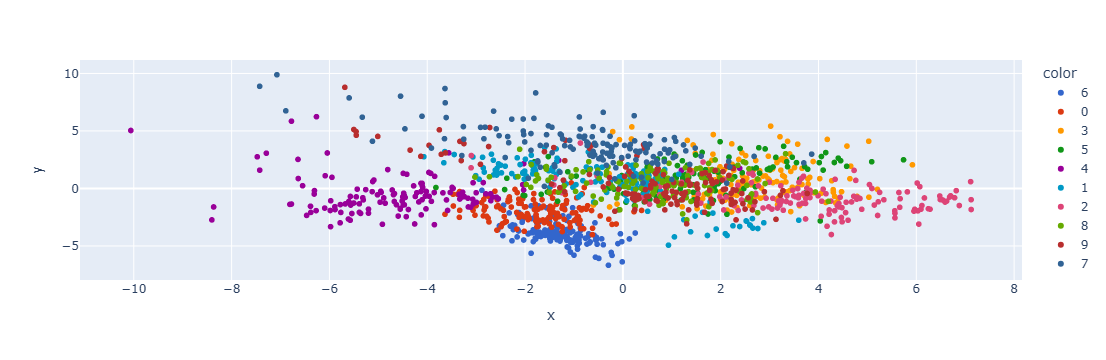

In [60]:
import plotly.express as px
y_train_pl=y_train.astype(str)
fig=px.scatter(x=X_train_pl[:,0],y=X_train_pl[:,1],color=y_train_pl,color_discrete_sequence=px.colors.qualitative.G10)
fig.show()

# Transformering In 3D

In [61]:
pca=PCA(n_components=3)
X_train_3d=pca.fit_transform(X_train)
X_test_3d=pca.transform(X_test)

In [62]:
X_train_3d

array([[-0.89165303, -4.74167035, -0.29068891],
       [-1.18767679, -1.85080876, -3.79579877],
       [-3.33677132, -1.90074688, -1.95577585],
       ...,
       [ 1.63986295,  2.2971521 ,  0.47282308],
       [-1.68953873,  1.84506575,  0.30431055],
       [-0.33256107, -0.34391184,  4.46957369]])

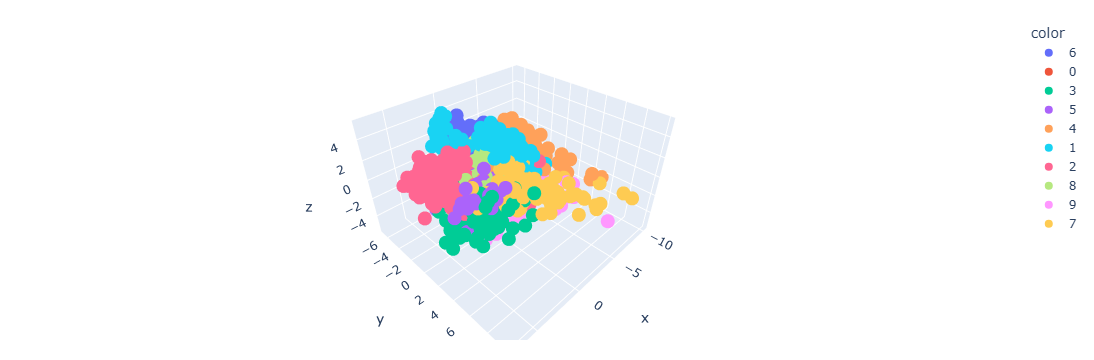

In [63]:
y_train_3d=y_train.astype(str)
fig=px.scatter_3d(X_train_3d,x=X_train_3d[:,0],y=X_train_3d[:,1],z=X_train_3d[:,2],color=y_train_3d)
fig.update_layout(margin=dict(l=20,r=20,t=20,b=20))
fig.show()

In [35]:
pca.explained_variance_
# Eigen values

array([7.34829746, 5.94132404, 5.22634794])

In [37]:
pca.explained_variance_ratio_


array([0.12038006, 0.09733098, 0.08561821])

In [38]:
pca.components_.shape
# Eigen vector

(3, 64)

In [39]:
np.cumsum(pca.explained_variance_ratio_)
#cummualtive sum

array([0.12038006, 0.21771104, 0.30332925])

# PCA hyper parameter N_component=None

In [40]:
pca=PCA(n_components=None)  # all column
X_train_all=pca.fit_transform(X_train)
X_test_all=pca.transform(X_test)

In [41]:
pca.explained_variance_
# Eigen  value for 64 column

array([7.34829746, 5.94132404, 5.22634794, 3.9639624 , 2.98370379,
       2.60288035, 2.41078635, 2.04469939, 1.84565832, 1.78972576,
       1.69211805, 1.55328502, 1.40584678, 1.3942606 , 1.29516327,
       1.15752216, 1.06666672, 0.9793297 , 0.96752926, 0.92102365,
       0.81781395, 0.77723097, 0.69481073, 0.63685256, 0.60149837,
       0.57220284, 0.52079707, 0.51047435, 0.48655041, 0.46237348,
       0.42754138, 0.42135594, 0.39245257, 0.37413281, 0.35055567,
       0.32821737, 0.30683083, 0.29060976, 0.2758448 , 0.26232547,
       0.25065525, 0.23742111, 0.2189737 , 0.20554898, 0.1943011 ,
       0.18767742, 0.17203634, 0.16530832, 0.15463594, 0.13914835,
       0.13150568, 0.11713476, 0.11444292, 0.10945711, 0.0980428 ,
       0.09357383, 0.08733835, 0.07861858, 0.07518781, 0.06322673,
       0.04764167, 0.        , 0.        , 0.        ])

In [42]:
pca.explained_variance_ratio_

array([0.12038006, 0.09733098, 0.08561821, 0.06493777, 0.04887914,
       0.04264048, 0.03949359, 0.03349634, 0.03023564, 0.02931935,
       0.02772034, 0.02544597, 0.02303063, 0.02284083, 0.02121741,
       0.01896257, 0.01747417, 0.01604341, 0.0158501 , 0.01508824,
       0.01339746, 0.01273262, 0.01138241, 0.01043294, 0.00985377,
       0.00937385, 0.00853172, 0.00836261, 0.00797069, 0.00757462,
       0.007004  , 0.00690267, 0.00642917, 0.00612906, 0.00574282,
       0.00537687, 0.00502651, 0.00476078, 0.0045189 , 0.00429742,
       0.00410624, 0.00388944, 0.00358723, 0.00336731, 0.00318305,
       0.00307454, 0.00281831, 0.00270809, 0.00253325, 0.00227953,
       0.00215433, 0.00191891, 0.00187481, 0.00179313, 0.00160614,
       0.00153293, 0.00143078, 0.00128793, 0.00123173, 0.00103578,
       0.00078047, 0.        , 0.        , 0.        ])

In [44]:
pca.components_.shape
# Eigen vector

(64, 64)

In [46]:
np.cumsum(pca.explained_variance_ratio_)
#cummlative Sum ---> 1+1=2 ,2+1=3 in series follow column

array([0.12038006, 0.21771104, 0.30332925, 0.36826702, 0.41714616,
       0.45978663, 0.49928022, 0.53277655, 0.56301219, 0.59233154,
       0.62005188, 0.64549785, 0.66852848, 0.6913693 , 0.71258671,
       0.73154928, 0.74902345, 0.76506686, 0.78091696, 0.7960052 ,
       0.80940266, 0.82213528, 0.8335177 , 0.84395064, 0.85380441,
       0.86317825, 0.87170997, 0.88007258, 0.88804326, 0.89561788,
       0.90262188, 0.90952455, 0.91595372, 0.92208277, 0.92782559,
       0.93320246, 0.93822897, 0.94298975, 0.94750865, 0.95180607,
       0.95591232, 0.95980176, 0.96338899, 0.9667563 , 0.96993935,
       0.97301389, 0.97583219, 0.97854028, 0.98107353, 0.98335306,
       0.98550739, 0.9874263 , 0.98930111, 0.99109424, 0.99270038,
       0.99423331, 0.99566409, 0.99695202, 0.99818375, 0.99921953,
       1.        , 1.        , 1.        , 1.        ])

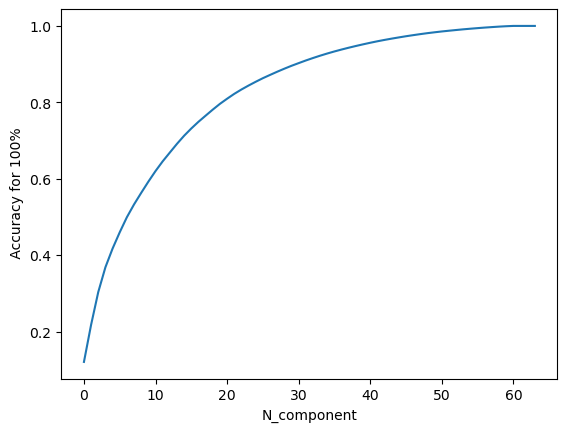

In [48]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("N_component")
plt.ylabel(" Accuracy for 100%")
plt.show()
# We need 90 percent data to used in n_componet show  then cut pint 9 to 29